# **Mini-projet : Predicting Heart Disease Using Logistic Regression**

## **Chargement des bibliothèques**

In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,ConfusionMatrixDisplay, classification_report

### **Data preparation**

#### **Chargement des données**

In [66]:
df = pd.read_csv('heart_disease_uci.csv')

In [67]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


Notre dataset comporte 920 échantillons répartis dans 15 variables :
* **age** : (Age of the patient in years)
* **origin** : (place of study)
* **sex** :  (Male/Female)
* **cp** :  chest pain type ([typical angina, atypical angina, non-anginal, asymptomatic])
* **trestbps** : resting blood pressure (resting blood pressure (in mm Hg on admission to the hospital))
* **chol** : (serum cholesterol in mg/dl)
* **fbs** : (if fasting blood sugar > 120 mg/dl)
* **restecg** (resting electrocardiographic results)
-- Values: [normal, stt abnormality, lv hypertrophy]
* **thalach** : maximum heart rate achieved
* **exang** : exercise-induced angina (True/ False)
* **oldpeak**: ST depression induced by exercise relative to rest
* **slope** : the slope of the peak exercise ST segment
* **ca**: number of major vessels (0-3) colored by fluoroscopy
* **thal** : [normal; fixed defect; reversible defect]
* **num** : the predicted attribute

In [69]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


Ici, on peut voir de façon globale comment nos données se présentent, notamment leurs valeurs minimales, maximales, l'écart types ou les quantiles ou encore la moyenne. On peut aussi aussi voir s'il y a des incohérences dans nos données. Ici, par exemple, on constate que pour la trestbps et chol, la valeur minimale est 0 or une pression artérielle au repos ou un taux de cholestérol sérique n'est généralement pas possible pour un patient vivant.
On peut alors corriger tout les incorhérences dans le jeu de données

In [70]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


On constate la présence de valeur manquante dans 10 variables (trestbps, chol, fbs, restecg, thalch, exang, oldpeak, slope, ca et thal). Nous allons les traités avant de passer à notre EDA

#### **Nettoyage des données (valeures manquantes et doublon)

In [71]:
df[df['chol']>300]

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
7,8,57,Female,Cleveland,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,upsloping,0.0,normal,0
26,27,58,Female,Cleveland,non-anginal,120.0,340.0,False,normal,172.0,False,0.0,upsloping,0.0,normal,0
32,33,64,Male,Cleveland,non-anginal,140.0,335.0,False,normal,158.0,False,0.0,upsloping,0.0,normal,1
38,39,55,Male,Cleveland,asymptomatic,132.0,353.0,False,normal,132.0,True,1.2,flat,1.0,reversable defect,3
42,43,71,Female,Cleveland,atypical angina,160.0,302.0,False,normal,162.0,False,0.4,upsloping,2.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
906,907,61,Male,VA Long Beach,non-anginal,120.0,337.0,False,normal,98.0,True,0.0,NaN,NaN,NaN,3
908,909,74,Male,VA Long Beach,asymptomatic,155.0,310.0,False,normal,112.0,True,1.5,downsloping,NaN,NaN,2
914,915,46,Male,VA Long Beach,asymptomatic,134.0,310.0,False,normal,126.0,False,0.0,NaN,NaN,normal,2
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1


In [72]:
df['trestbps'] = df['trestbps'].replace(0, np.nan)

In [73]:
df['trestbps'] = df['trestbps'].fillna(df['trestbps'].mean())

In [74]:
df['chol'] = df['chol'].replace(0, np.nan)
df['chol'] = df['chol'].fillna(df['chol'].mean())

In [75]:
imputer = KNNImputer(n_neighbors=5)
df['fbs'] = df['fbs'].fillna('Non renseigné')

In [76]:
df['restecg'].unique()

array(['lv hypertrophy', 'normal', 'st-t abnormality', nan], dtype=object)

In [77]:
df['restecg'] = df['restecg'].fillna('Non renseigné')

In [78]:
df['thalch'] = df['thalch'].replace(0, np.nan)
df['thalch'] = df['thalch'].fillna(df['thalch'].mean())

In [79]:
df['exang'] = df['exang'].fillna('Non renseigné')

In [80]:
df['oldpeak'] = imputer.fit_transform(df[['oldpeak']])

In [81]:
df['slope'].unique()

array(['downsloping', 'flat', 'upsloping', nan], dtype=object)

In [82]:

df['slope'] = df['slope'].fillna('Non renseigné')

In [83]:
df['ca'].unique()

array([ 0.,  3.,  2.,  1., nan])

In [84]:
df['ca'] = imputer.fit_transform(df[['ca']])

In [85]:
df['thal'].unique()
df['thal'] = df['thal'].fillna('Non renseigné')

In [86]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0


Nous avons néttoyer toute les valeurs manquantes issu de notre jeu de données, nouq pouvons passer à l'étape suivante

In [87]:
dataset = df['dataset']
df = df.drop('dataset', axis=1)
df = df.drop('id', axis=1)

In [88]:
df.duplicated().sum()

np.int64(2)

In [89]:
df = df.drop_duplicates()

On constate qu'il n'y pas de valeur dupliquer

On constate qu'il y a des valeurs extrème, nous allons donc les traiter

#### **Analyse descriptive**

#### **Analyse descriptive univariée**

In [90]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [91]:
df['sex'].value_counts()

,count
sex,
Male,725
Female,193


Les hommes sont plus atteint par les maladies cardiaques que les femmes

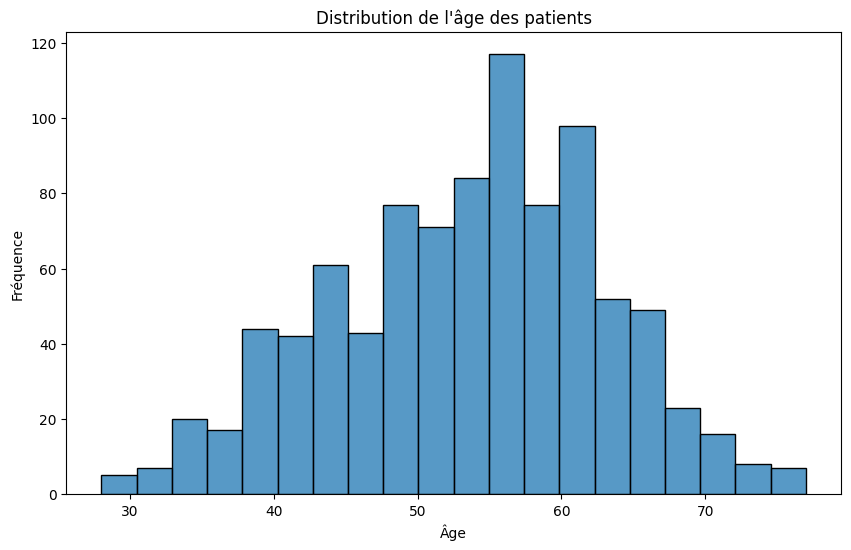

In [92]:
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=20)
plt.title('Distribution de l\'âge des patients')
plt.xlabel('Âge')
plt.ylabel('Fréquence')
plt.show()

La majorité des personne atteint par les maladies cardiaque se situent entre 48 et 63 ans

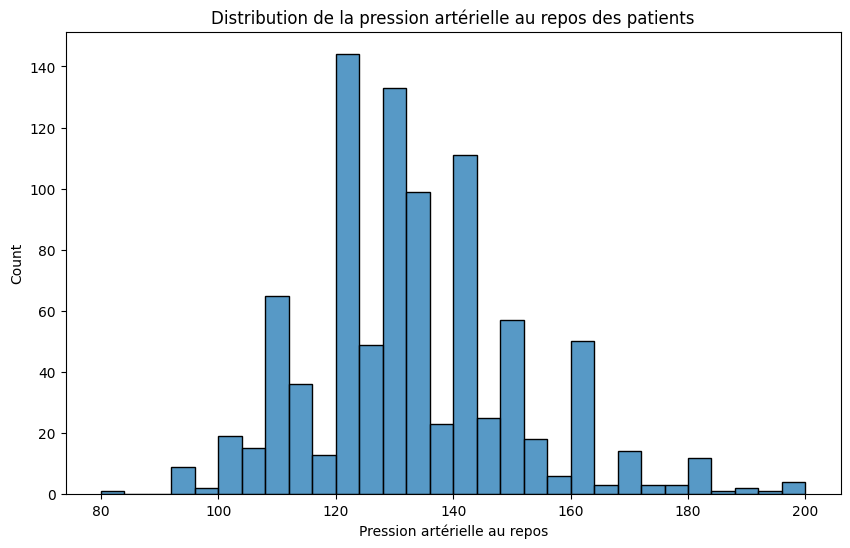

In [93]:
plt.figure(figsize=(10, 6))
sns.histplot(df['trestbps'])
plt.title('Distribution de la pression artérielle au repos des patients')
plt.xlabel('Pression artérielle au repos');

La pression arterielle se situe généralement entre 120 et 150 mm Hg

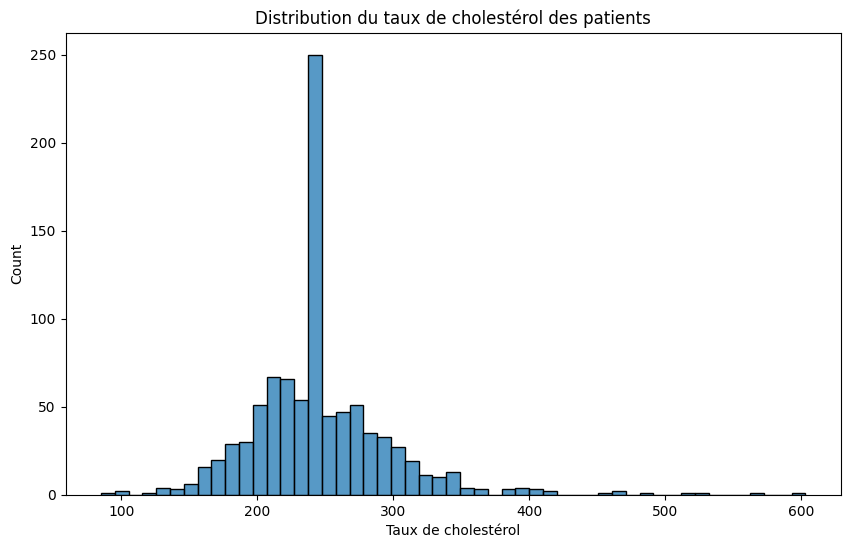

In [94]:
plt.figure(figsize=(10, 6))
sns.histplot(df['chol'])
plt.title('Distribution du taux de cholestérol des patients')
plt.xlabel('Taux de cholestérol');

Le taux de cholestérol varie entre 100 et 600 mg/dl.  
On constate aussi que le taux de cholestérol globale se situe entre 200 et 300 mg/dl

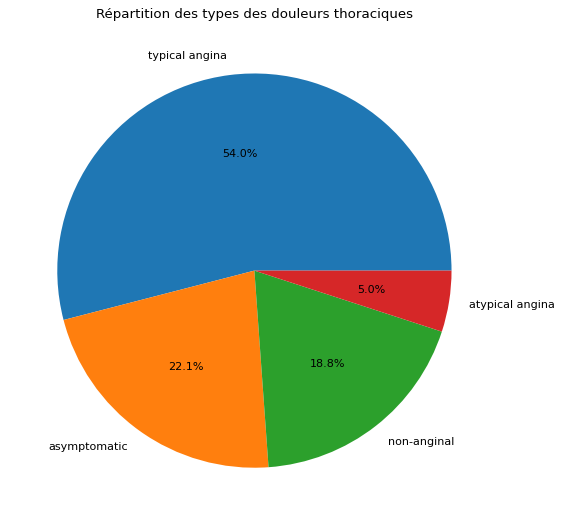

In [95]:
plt.figure(figsize=(10, 8),dpi = 80)
plt.pie(df['cp'].value_counts(), labels=df['cp'].unique(), autopct='%1.1f%%')
plt.title('Répartition des types des douleurs thoraciques')
plt.show();

In [96]:
df['num'].value_counts()

,count
num,
0,410
1,265
2,108
3,107
4,28


On voit que les patients atteint de la catégorie 0 sont les plus nombreux

#### **Analyse descriptive bivariée**

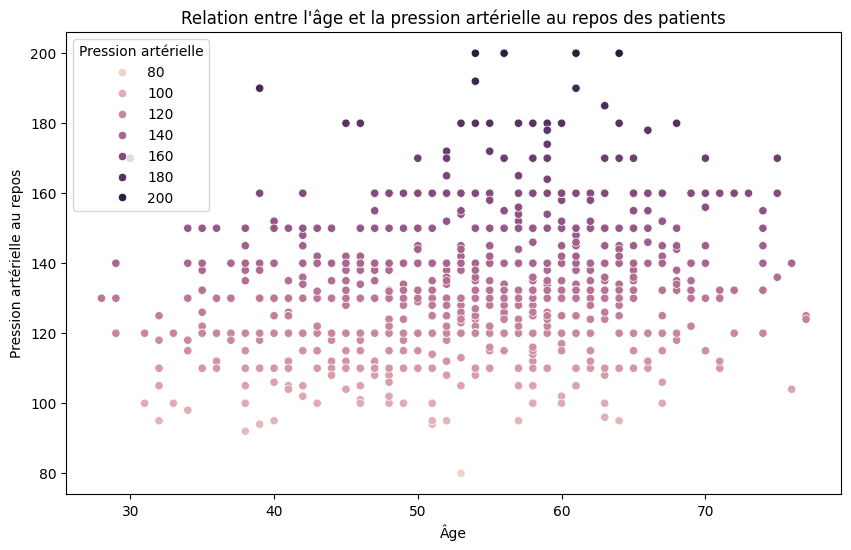

In [97]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='trestbps', data=df,hue='trestbps')
plt.title('Relation entre l\'âge et la pression artérielle au repos des patients')
plt.xlabel('Âge')
plt.ylabel('Pression artérielle au repos')
plt.legend(title='Pression artérielle', )
plt.show()

On peut remarquer qu'ici, le taux de pression artérielle  augmente, cette catégorie est plus à risque de faire des attaques

In [98]:
plt.figure(figsize=(10, 8))
sns

<module 'seaborn' from '/usr/local/lib/python3.12/dist-packages/seaborn/__init__.py'>

<Figure size 1000x800 with 0 Axes>

In [99]:
tableau_contingence = pd.crosstab(df['sex'], df['num'])
print(tableau_contingence)

num       0    1   2   3   4
sex                         
Female  143   30  10   8   2
Male    267  235  98  99  26


Dans chaque catégorie, les hommes sont la catégorie qui sont plus atteint par les maladies cardiaques

#### **Feature engineering**

In [100]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [101]:
df['sex'] = df['sex'].map({
    'Male' : 0,
    'Female' : 1
})

In [102]:
df['cp'].unique()

array(['typical angina', 'asymptomatic', 'non-anginal', 'atypical angina'],
      dtype=object)

In [103]:
df['cp'] = df['cp'].map({
    'typical angina' : 0,
    'asymptomatic' : 1,
    'non-anginal' : 2,
    'atypical angina' : 3})

In [104]:
df['restecg'].unique()

array(['lv hypertrophy', 'normal', 'st-t abnormality', 'Non renseigné'],
      dtype=object)

In [105]:
df['restecg'] = df['restecg'].map({
    'normal' : 0,
    'lv hypertrophy' : 1,
    'st-t abnormality' : 2,
    'Non renseigné' : 4
})

In [106]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,0,0,145.0,233.0,True,1,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,0,1,160.0,286.0,False,1,108.0,True,1.5,flat,3.0,normal,2
2,67,0,1,120.0,229.0,False,1,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,0,2,130.0,250.0,False,0,187.0,False,3.5,downsloping,0.0,normal,0
4,41,1,3,130.0,204.0,False,1,172.0,False,1.4,upsloping,0.0,normal,0


In [107]:
df['fbs'] = df['fbs'].map({
    True : 1,
    False : 0,
    'Non renseigné' : 2
})

In [108]:
df['exang'].unique()

array([False, True, 'Non renseigné'], dtype=object)

In [109]:
df['exang'] = df['exang'].map({
    True : 1,
    False : 0,
    'Non renseigné' : 2
})

In [110]:
df['slope'].unique()

array(['downsloping', 'flat', 'upsloping', 'Non renseigné'], dtype=object)

In [111]:
df['slope'] = df['slope'].map({
    'upsloping' : 0,
    'flat' : 1,
    'downsloping' : 2,
    'Non renseigné' : 3
})

In [112]:
df['slope'].unique()

array([2, 1, 0, 3])

In [113]:
df['thal'].unique()

array(['fixed defect', 'normal', 'reversable defect', 'Non renseigné'],
      dtype=object)

In [114]:
df['thal'] = df['thal'].map({
    'normal' : 0,
    'fixed defect' : 1,
    'reversable defect' : 2,
    'Non renseigné' : 3
})

In [115]:
df['thal'].unique()

array([1, 0, 2, 3])

In [116]:
correlation_with_num = df.corr()['num'].sort_values(ascending=False)
print(correlation_with_num)

num         1.000000
oldpeak     0.422587
age         0.339053
exang       0.337129
ca          0.321672
fbs         0.186882
restecg     0.164418
trestbps    0.132095
thal        0.089506
chol        0.058104
slope      -0.088229
sex        -0.257791
thalch     -0.350024
cp         -0.377241
Name: num, dtype: float64


On peut voir ici qu'il y a une forte corrélation entre la catégorie le maladie cardiaque et certaine variable comme oldpeak, age, l'exang, le ca, fbs, restecg et trestbps

In [121]:
new_df = df[['oldpeak','age','exang','ca','fbs','restecg','trestbps','num']]

In [123]:
new_df.head()

,oldpeak,age,exang,ca,fbs,restecg,trestbps,num
0,2.3,63,0,0.0,1,1,145.0,0
1,1.5,67,1,3.0,0,1,160.0,2
2,2.6,67,1,2.0,0,1,120.0,1
3,3.5,37,0,0.0,0,0,130.0,0
4,1.4,41,0,0.0,0,1,130.0,0


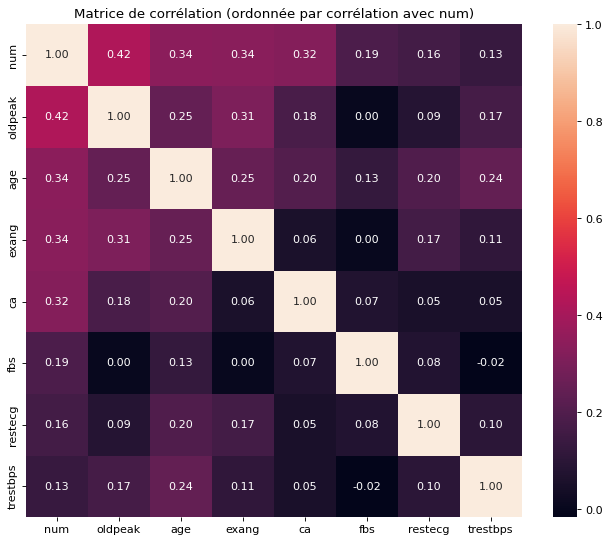

In [126]:
plt.figure(figsize=(10, 8),dpi=80)

# Calculate the correlation matrix
corr_matrix = new_df.corr()

# Sort features by their absolute correlation with 'num'
sorted_features = corr_matrix['num'].abs().sort_values(ascending=False).index

# Reorder the correlation matrix based on sorted features
sorted_corr_matrix = corr_matrix.loc[sorted_features, sorted_features]

sns.heatmap(sorted_corr_matrix, annot=True, fmt=".2f")
plt.title('Matrice de corrélation')
plt.show()

### **Model training**

In [127]:
X = new_df.drop('num', axis=1)
y = new_df['num']

In [131]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### **Regression logistique sans Grid Search**

In [133]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [135]:
lr = LogisticRegression(class_weight='balanced')
lr.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced')

In [136]:
y_pred = lr.predict(X_test_scaled)

#### **Regression logistique avec Grid Search**

In [140]:
lr_param = {
    'C' : [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'penalty' : ['l1', 'l2'],
    'max_iter' : [100, 200, 300, 400, 500]
}

In [141]:
gs = GridSearchCV(lr,lr_param, cv = 5)

In [142]:
gs.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
175 fits failed out of a total of 350.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
175 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_sol

GridSearchCV(cv=5, estimator=LogisticRegression(class_weight='balanced'),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
                         'max_iter': [100, 200, 300, 400, 500],
                         'penalty': ['l1', 'l2']})

In [143]:
gs.best_params_

{'C': 1, 'max_iter': 100, 'penalty': 'l2'}

In [144]:
best_lr = LogisticRegression(C=1, class_weight='balanced', max_iter=100, penalty='l2')

In [145]:
best_lr.fit(X_train_scaled, y_train)

LogisticRegression(C=1, class_weight='balanced')

In [146]:
best_y = best_lr.predict(X_test_scaled)

### **Model evaluation**

#### **Sans GridSearch**

In [150]:
no_grid_accuracy = accuracy_score(y_test, y_pred)
no_grid_precision = precision_score(y_test, y_pred, average='weighted')
no_grid_recall = recall_score(y_test, y_pred, average='weighted')
no_grid_f1 = f1_score(y_test, y_pred, average='weighted')

In [151]:
print("Accuracy:", no_grid_accuracy)
print("Precision:", no_grid_precision)
print("Recall:", no_grid_recall)
print("F1 Score:", no_grid_f1)

Accuracy: 0.45652173913043476
Precision: 0.4994355006996784
Recall: 0.45652173913043476
F1 Score: 0.46961769237523115


#### **Avec GridSearch**

In [152]:
with_grid_accuracy = accuracy_score(y_test, best_y)
with_grid_precision = precision_score(y_test, best_y, average='weighted')
with_grid_recall = recall_score(y_test, best_y, average='weighted')
with_grid_f1 = f1_score(y_test, best_y, average='weighted')

In [153]:
print("Accuracy:", with_grid_accuracy)
print("Precision:", with_grid_precision)
print("Recall:", with_grid_recall)
print("F1 Score:", with_grid_f1)

Accuracy: 0.45652173913043476
Precision: 0.4994355006996784
Recall: 0.45652173913043476
F1 Score: 0.46961769237523115


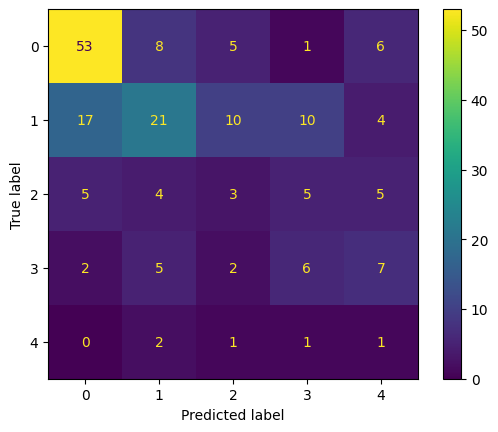

In [155]:
ConfusionMatrixDisplay.from_estimator(best_lr, X_test_scaled, y_test)
plt.show()

Pour la classe 2, le modèle n'arrive pas à les distinguer à la classe 0, 3 et 4.  
Pour la classe 4, le modèle n'arrive pas à le différencier des autres classe

In [158]:
print(classification_report(y_test, best_y))

              precision    recall  f1-score   support

           0       0.69      0.73      0.71        73
           1       0.53      0.34      0.41        62
           2       0.14      0.14      0.14        22
           3       0.26      0.27      0.27        22
           4       0.04      0.20      0.07         5

    accuracy                           0.46       184
   macro avg       0.33      0.33      0.32       184
weighted avg       0.50      0.46      0.47       184



In [162]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.73      0.71        73
           1       0.53      0.34      0.41        62
           2       0.14      0.14      0.14        22
           3       0.26      0.27      0.27        22
           4       0.04      0.20      0.07         5

    accuracy                           0.46       184
   macro avg       0.33      0.33      0.32       184
weighted avg       0.50      0.46      0.47       184



On remarque que le modèle distingue facilement la classe 0 et 1 contrairement aux autres classes

### **Suggestion**

In [165]:
df['num'].value_counts()

,count
num,
0,410
1,265
2,108
3,107
4,28


* Données déséquiblibré pour certaine classe (notamment pour la classe 4)
* Il se serait aussi essentiel de d'augmenter la taille des données